# Sleep Disorder Prediction — ML Analysis

**Goal:** Predict sleep disorders (Insomnia / Sleep Apnea / None) based on lifestyle and physiological features.

**Dataset:** Sleep Health and Lifestyle Dataset, 374 people, 12 features  
**Models:** Random Forest, XGBoost  
**Author:** Vadim Vovnenko

## 1. Data Loading

In [1]:
import pandas as pd

df = pd.read_csv('sleep_data.csv', keep_default_na=False)
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,43,Accountant,8.5,8,79,3,Normal,124/93,65,6854,None
1,2,Female,52,Lawyer,6.5,9,51,7,Normal Weight,135/78,68,6494,None
2,3,Female,34,Salesperson,5.8,7,81,7,Normal,132/93,77,4914,Insomnia
3,4,Female,55,Software Engineer,6.3,8,59,4,Overweight,121/85,77,6072,Insomnia
4,5,Male,52,Accountant,6.9,4,49,6,Normal,117/76,77,4006,Insomnia


## 2. Exploratory Data Analysis (EDA)
Exploring data structure, class distribution, and correlations.

In [2]:
print(df.shape)
print(df.dtypes)
print(df['Sleep Disorder'].value_counts())

(374, 13)
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object
Sleep Disorder
None           291
Insomnia        66
Sleep Apnea     17
Name: count, dtype: int64


In [3]:
df.isnull().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [4]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.655080,7.189572,6.564171,60.729947,5.553476,74.975936,6336.858289
std,108.108742,9.395468,0.828108,1.706289,17.070876,1.709797,6.014902,1920.934253
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3018.000000
25%,94.250000,35.000000,6.600000,5.000000,47.250000,4.000000,70.000000,4723.250000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,6.000000,75.000000,6354.000000
75%,280.750000,51.000000,7.900000,8.000000,75.750000,7.000000,80.000000,7916.750000
max,374.000000,59.000000,8.500000,9.000000,89.000000,8.000000,85.000000,9996.000000


In [5]:
print(df['Gender'].value_counts())
print()
print(df['BMI Category'].value_counts())
print()
print(df['Occupation'].value_counts())

Gender
Male      209
Female    165
Name: count, dtype: int64

BMI Category
Normal           130
Overweight       110
Normal Weight     83
Obese             51
Name: count, dtype: int64

Occupation
Nurse                55
Engineer             49
Teacher              49
Lawyer               47
Salesperson          44
Software Engineer    37
Accountant           31
Doctor               25
Manager              22
Scientist            15
Name: count, dtype: int64


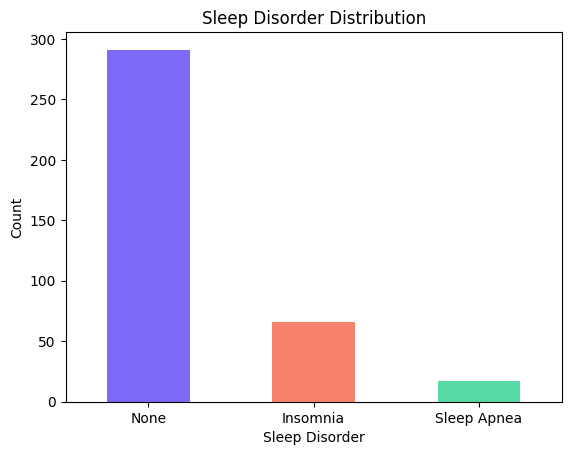

In [6]:
import matplotlib.pyplot as plt

df['Sleep Disorder'].value_counts().plot(kind='bar', color=['#7c6af7','#f9826c','#56d9a3'])
plt.title('Sleep Disorder Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 3. Data Preprocessing

Issues found during EDA:
- Person ID — no predictive value, dropped
- BMI Category — duplicate values "Normal" and "Normal Weight", merged
- Blood Pressure — string format "120/80", split into two numeric features
- Categorical columns — encoded with LabelEncoder
- Class imbalance — None 78%, addressed with SMOTE

In [7]:
# Step 1. Drop Person ID — just a row number, no predictive value
df = df.drop(columns=['Person ID'])

# Step 2. Fix duplicate BMI values
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# Step 3. Split Blood Pressure "120/80" into two numeric features
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood Pressure'])

print(df.shape)
print(df.columns.tolist())

(374, 13)
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP']


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical columns
df['Gender'] = le.fit_transform(df['Gender'])

le_occupation = LabelEncoder()
df['Occupation'] = le_occupation.fit_transform(df['Occupation'])

le_bmi = LabelEncoder()
df['BMI Category'] = le_bmi.fit_transform(df['BMI Category'])

# Encode target separately — we need to keep the class mapping
le_target = LabelEncoder()
df['Sleep Disorder'] = le_target.fit_transform(df['Sleep Disorder'])

print("Sleep Disorder Classes:", le_target.classes_)
print(df['Sleep Disorder'].value_counts())

Sleep Disorder Classes: ['Insomnia' 'None' 'Sleep Apnea']
Sleep Disorder
1    291
0     66
2     17
Name: count, dtype: int64


In [9]:
# X — all features (everything except the target)
# y — target variable
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (374, 12)
y shape: (374,)


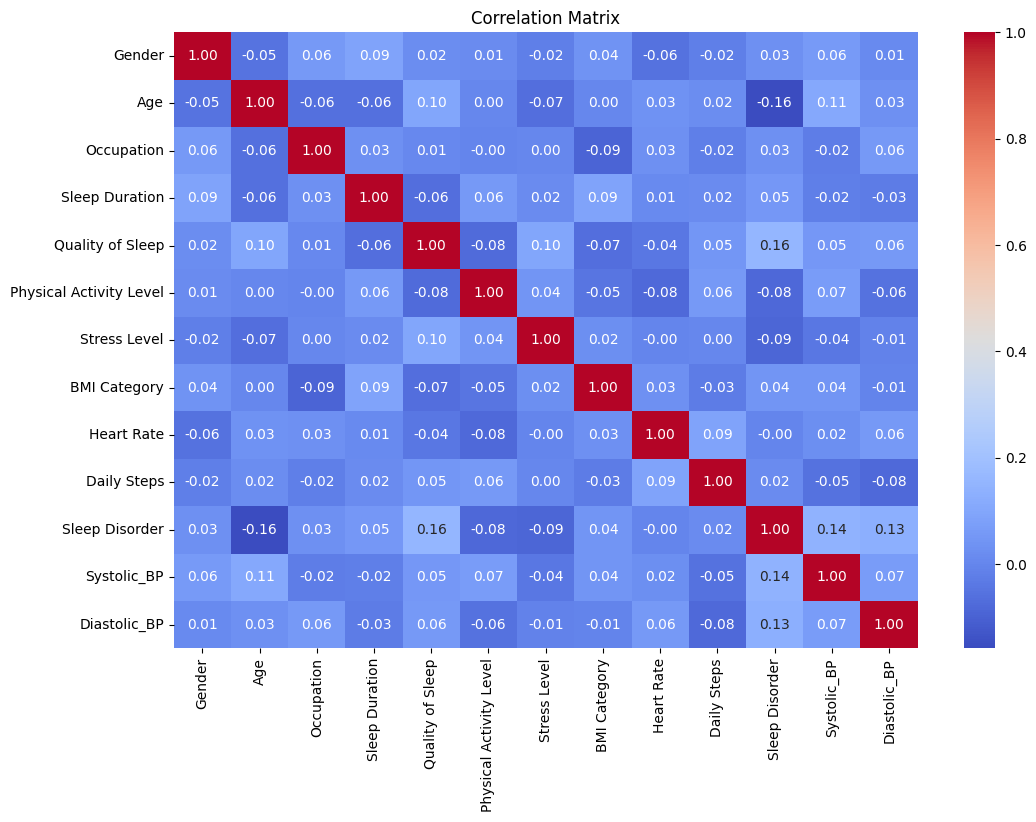

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (299, 12)
Test: (75, 12)


## 4. Modeling

Correlation analysis showed weak linear relationships between features.
Tree-based models (Random Forest, XGBoost) were selected as they capture
non-linear dependencies that linear models would miss.

SMOTE was applied only to training data. Test set remains original
to reflect real-world class distribution.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Model trained")

Model trained


In [13]:
y_pred = rf.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual:     ", y_test.values[:10])

First 10 predictions: [1 1 1 1 1 1 1 1 1 1]
First 10 actual:      [1 0 1 2 0 1 1 0 1 1]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=list(le_target.classes_), zero_division=0))

              precision    recall  f1-score   support

    Insomnia       0.50      0.15      0.24        13
        None       0.82      1.00      0.90        58
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.80        75
   macro avg       0.44      0.38      0.38        75
weighted avg       0.72      0.80      0.74        75



In [15]:
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'  # вот это добавили
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_target.classes_, zero_division=0))

              precision    recall  f1-score   support

    Insomnia       0.40      0.15      0.22        13
        None       0.81      0.98      0.89        58
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.79        75
   macro avg       0.40      0.38      0.37        75
weighted avg       0.70      0.79      0.73        75



In [16]:
import numpy as np

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE: ", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))

Before SMOTE:  {np.int64(0): np.int64(53), np.int64(1): np.int64(233), np.int64(2): np.int64(13)}
After SMOTE: {np.int64(0): np.int64(233), np.int64(1): np.int64(233), np.int64(2): np.int64(233)}


In [18]:
rf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred_sm = rf_sm.predict(X_test)

print(classification_report(y_test, y_pred_sm, target_names=le_target.classes_, zero_division=0))

              precision    recall  f1-score   support

    Insomnia       0.42      0.38      0.40        13
        None       0.87      0.91      0.89        58
 Sleep Apnea       0.50      0.25      0.33         4

    accuracy                           0.79        75
   macro avg       0.60      0.52      0.54        75
weighted avg       0.77      0.79      0.78        75



## 5. Evaluation

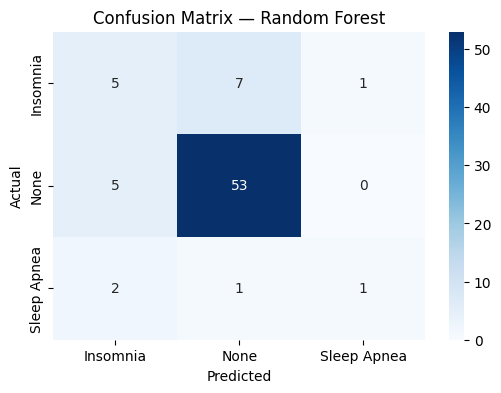

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_sm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, 
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, 
      target_names=le_target.classes_, zero_division=0))

              precision    recall  f1-score   support

    Insomnia       0.43      0.46      0.44        13
        None       0.90      0.90      0.90        58
 Sleep Apnea       0.67      0.50      0.57         4

    accuracy                           0.80        75
   macro avg       0.66      0.62      0.64        75
weighted avg       0.80      0.80      0.80        75



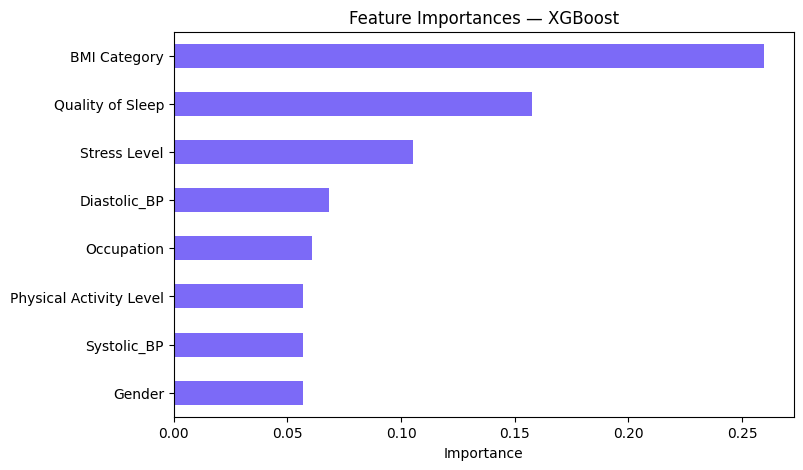

BMI Category               0.259697
Quality of Sleep           0.157558
Stress Level               0.105124
Diastolic_BP               0.068163
Occupation                 0.060624
Physical Activity Level    0.057009
Systolic_BP                0.056829
Gender                     0.056753
dtype: float32


In [21]:
fi = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True).tail(8)

fi.plot(kind='barh', figsize=(8, 5), color='#7c6af7')
plt.title('Feature Importances — XGBoost')
plt.xlabel('Importance')
plt.show()

print(fi.sort_values(ascending=False))

## 6. Conclusions

**Best model:** XGBoost + SMOTE

| Class | Recall |
|---|---|
| None | 0.90 |
| Insomnia | 0.46 |
| Sleep Apnea | 0.50 |

**Most important feature:** BMI Category — medically justified,
obesity is directly linked to Sleep Apnea through airway obstruction.

**Limitations:**
- Small dataset (374 people) — minority classes are underrepresented
- SMOTE generates synthetic data, not real clinical cases
- Real clinical data (PSG, EEG signals) would significantly improve results